In [5]:
import pandas as pd
import numpy as np

df = pd.read_csv("../data/uber_rides.csv")

df.head()

,datetime,Date,Time,year,month,day,weekday,hour,ride_date,Event,...,Avg CTAT,Cancelled Rides by Customer,Reason for cancelling by Customer,Cancelled Rides by Driver,Driver Cancellation Reason,Incomplete Rides,Incomplete Rides Reason,Driver Ratings,Customer Rating,Payment Method
0,2024-03-23 12:29:38,2024-03-23,12:29:38,2024,3,23,Saturday,12,2024-03-23,Normal Day,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2024-11-29 18:01:39,2024-11-29,18:01:39,2024,11,29,Friday,18,2024-11-29,Wedding_Season,...,14.0,NaN,NaN,NaN,NaN,1.0,Vehicle Breakdown,NaN,NaN,UPI
2,2024-08-23 08:56:10,2024-08-23,08:56:10,2024,8,23,Friday,8,2024-08-23,Monsoon,...,25.8,NaN,NaN,NaN,NaN,NaN,NaN,4.9,4.9,Debit Card
3,2024-10-21 17:17:25,2024-10-21,17:17:25,2024,10,21,Monday,17,2024-10-21,Normal Day,...,28.5,NaN,NaN,NaN,NaN,NaN,NaN,4.6,5.0,UPI
4,2024-09-16 22:08:00,2024-09-16,22:08:00,2024,9,16,Monday,22,2024-09-16,Normal Day,...,19.6,NaN,NaN,NaN,NaN,NaN,NaN,4.1,4.3,UPI


In [6]:
print("Dataset Shape:", df.shape)
print(df.columns.tolist())

Dataset Shape: (160609, 29)
['datetime', 'Date', 'Time', 'year', 'month', 'day', 'weekday', 'hour', 'ride_date', 'Event', 'Booking ID', 'Booking Status', 'Customer ID', 'Vehicle Type', 'Pickup Location', 'Drop Location', 'Ride Distance', 'Booking Value', 'Avg VTAT', 'Avg CTAT', 'Cancelled Rides by Customer', 'Reason for cancelling by Customer', 'Cancelled Rides by Driver', 'Driver Cancellation Reason', 'Incomplete Rides', 'Incomplete Rides Reason', 'Driver Ratings', 'Customer Rating', 'Payment Method']


In [7]:
df.isnull().sum()

datetime                                  0
Date                                      0
Time                                      0
year                                      0
month                                     0
day                                       0
weekday                                   0
hour                                      0
ride_date                                 0
Event                                     0
Booking ID                                0
Booking Status                            0
Customer ID                               0
Vehicle Type                              0
Pickup Location                           0
Drop Location                             0
Ride Distance                         51280
Booking Value                         51280
Avg VTAT                              11207
Avg CTAT                              51280
Cancelled Rides by Customer          149355
Reason for cancelling by Customer    149355
Cancelled Rides by Driver       

In [8]:
print(df.columns.tolist())

['datetime', 'Date', 'Time', 'year', 'month', 'day', 'weekday', 'hour', 'ride_date', 'Event', 'Booking ID', 'Booking Status', 'Customer ID', 'Vehicle Type', 'Pickup Location', 'Drop Location', 'Ride Distance', 'Booking Value', 'Avg VTAT', 'Avg CTAT', 'Cancelled Rides by Customer', 'Reason for cancelling by Customer', 'Cancelled Rides by Driver', 'Driver Cancellation Reason', 'Incomplete Rides', 'Incomplete Rides Reason', 'Driver Ratings', 'Customer Rating', 'Payment Method']


In [9]:
print("Dataset Shape:", df.shape)

print("\nColumns:")
for col in df.columns:
    print(col)

Dataset Shape: (160609, 29)

Columns:
datetime
Date
Time
year
month
day
weekday
hour
ride_date
Event
Booking ID
Booking Status
Customer ID
Vehicle Type
Pickup Location
Drop Location
Ride Distance
Booking Value
Avg VTAT
Avg CTAT
Cancelled Rides by Customer
Reason for cancelling by Customer
Cancelled Rides by Driver
Driver Cancellation Reason
Incomplete Rides
Incomplete Rides Reason
Driver Ratings
Customer Rating
Payment Method


In [10]:
df.dtypes

datetime                              object
Date                                  object
Time                                  object
year                                   int64
month                                  int64
day                                    int64
weekday                               object
hour                                   int64
ride_date                             object
Event                                 object
Booking ID                            object
Booking Status                        object
Customer ID                           object
Vehicle Type                          object
Pickup Location                       object
Drop Location                         object
Ride Distance                        float64
Booking Value                        float64
Avg VTAT                             float64
Avg CTAT                             float64
Cancelled Rides by Customer          float64
Reason for cancelling by Customer     object
Cancelled 

In [11]:
df.isnull().sum()

datetime                                  0
Date                                      0
Time                                      0
year                                      0
month                                     0
day                                       0
weekday                                   0
hour                                      0
ride_date                                 0
Event                                     0
Booking ID                                0
Booking Status                            0
Customer ID                               0
Vehicle Type                              0
Pickup Location                           0
Drop Location                             0
Ride Distance                         51280
Booking Value                         51280
Avg VTAT                              11207
Avg CTAT                              51280
Cancelled Rides by Customer          149355
Reason for cancelling by Customer    149355
Cancelled Rides by Driver       

In [12]:
df.columns.tolist()

['datetime',
 'Date',
 'Time',
 'year',
 'month',
 'day',
 'weekday',
 'hour',
 'ride_date',
 'Event',
 'Booking ID',
 'Booking Status',
 'Customer ID',
 'Vehicle Type',
 'Pickup Location',
 'Drop Location',
 'Ride Distance',
 'Booking Value',
 'Avg VTAT',
 'Avg CTAT',
 'Cancelled Rides by Customer',
 'Reason for cancelling by Customer',
 'Cancelled Rides by Driver',
 'Driver Cancellation Reason',
 'Incomplete Rides',
 'Incomplete Rides Reason',
 'Driver Ratings',
 'Customer Rating',
 'Payment Method']

In [13]:
cancelled = df[
    df["Booking Status"].isin(
        [
            "Cancelled by Customer",
            "Cancelled by Driver"
        ]
    )
]

cancellation_rate = len(cancelled) / len(df) * 100

print(f"Cancellation Rate: {cancellation_rate:.2f}%")

Cancellation Rate: 24.95%


In [14]:
df["Booking Status"].value_counts()

Booking Status
Completed                99666
Cancelled by Driver      28819
Cancelled by Customer    11254
No Driver Found          11207
Incomplete                9663
Name: count, dtype: int64

In [15]:
cancelled["Vehicle Type"].value_counts()

Vehicle Type
Auto             9976
Go Mini          7909
Go Sedan         7294
Bike             6044
Premier Sedan    4864
eBike            2821
Uber XL          1165
Name: count, dtype: int64

In [16]:
df["Reason for cancelling by Customer"].value_counts()

Reason for cancelling by Customer
Change of plans                                 2531
Wrong Address                                   2515
Driver is not moving towards pickup location    2512
Driver asked to cancel                          2452
AC is not working                               1244
Name: count, dtype: int64

In [17]:
df["Driver Cancellation Reason"].value_counts()

Driver Cancellation Reason
Customer related issue                 7282
The customer was coughing/sick         7211
Personal & Car related issues          7176
More than permitted people in there    7150
Name: count, dtype: int64

In [18]:
cancelled["hour"].value_counts().sort_index()

hour
0      370
1      370
2      315
3      373
4      359
5      786
6     1092
7     1468
8     1824
9     2196
10    2548
11    2156
12    1865
13    1467
14    1956
15    2243
16    2531
17    2923
18    3347
19    3043
20    2536
21    2070
22    1490
23     745
Name: count, dtype: int64

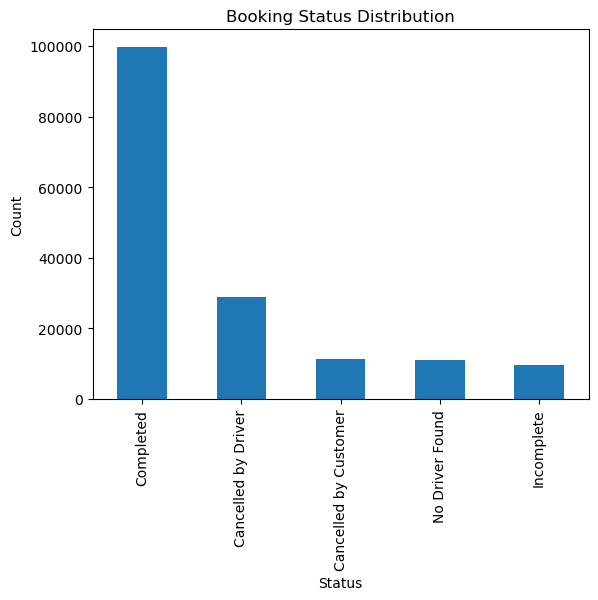

In [19]:
import matplotlib.pyplot as plt

df["Booking Status"].value_counts().plot(kind="bar")

plt.title("Booking Status Distribution")
plt.xlabel("Status")
plt.ylabel("Count")

plt.show()

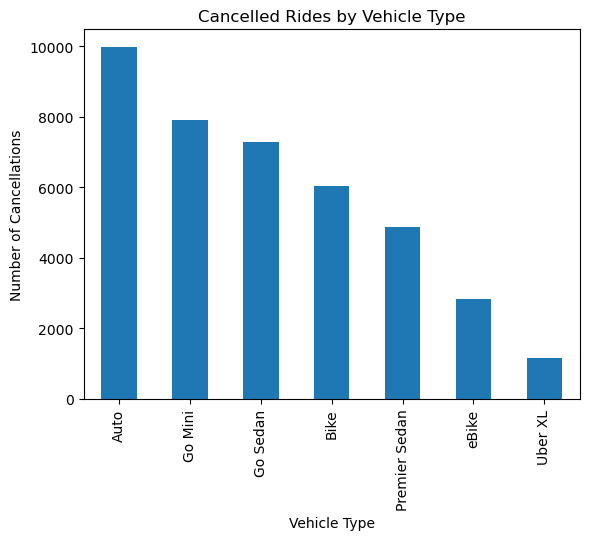

In [20]:
cancelled["Vehicle Type"].value_counts().plot(kind="bar")

plt.title("Cancelled Rides by Vehicle Type")
plt.xlabel("Vehicle Type")
plt.ylabel("Number of Cancellations")

plt.show()

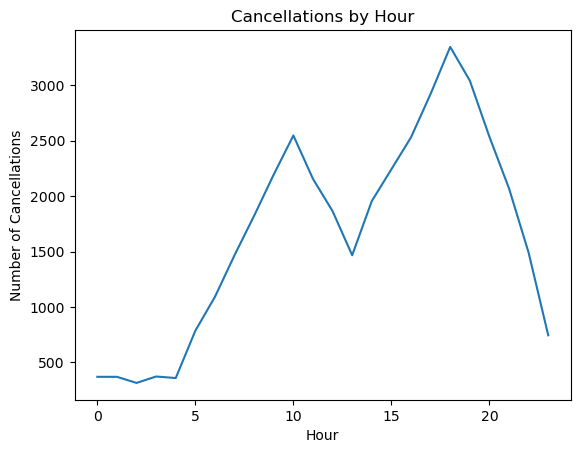

In [21]:
cancelled["hour"].value_counts().sort_index().plot(kind="line")

plt.title("Cancellations by Hour")
plt.xlabel("Hour")
plt.ylabel("Number of Cancellations")

plt.show()

In [ ]:
## Conclusion

The exploratory analysis revealed that approximately 25% of all ride bookings result in cancellations. Auto vehicles experienced the highest number of cancellations among all vehicle categories. The most common customer cancellation reason was a change of plans, while customer-related issues were the leading cause of driver cancellations. Cancellation activity peaked during the evening hours, particularly around 6 PM, indicating higher operational challenges during peak demand periods. These insights will guide feature selection and model development in the next phase of the project.
